In [90]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from eomaps import Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.path import shapely_to_path
from shapely.ops import unary_union
import geopandas as gpd
import os


%matplotlib widget

In [91]:
gkg = None
for file in os.listdir("C:/Users/ottos/Documents/Geomatik/2. Sem/AICoding/data/gkgcounts"):
    temp = pd.read_csv(f"C:/Users/ottos/Documents/Geomatik/2. Sem/AICoding/data/gkgcounts/{file}", header=0, delimiter="\t")
    if gkg is not None:
        gkg = pd.concat([gkg, temp], ignore_index=True)

    else:
        gkg = temp


gkg.dropna(subset=["GEO_LAT", "GEO_LONG"], inplace=True)
gkg

,DATE,NUMARTS,COUNTTYPE,NUMBER,OBJECTTYPE,GEO_TYPE,GEO_FULLNAME,GEO_COUNTRYCODE,GEO_ADM1CODE,GEO_LAT,GEO_LONG,GEO_FEATUREID,CAMEOEVENTIDS,SOURCES,SOURCEURLS
0,20260301,1,CRISISLEX_T01_CAUTION_ADVICE,2014,measures,1,India,IN,IN,20.000000,77.000000,IN,"1291712689,1291712781,1291712782,1291712788,12...",indianexpress.com,https://indianexpress.com/article/cities/kolka...
1,20260301,1,CRISISLEX_CRISISLEXREC,2,NaN,4,"Tredegar, Blaenau Gwent, United Kingdom",UK,UKX2,51.783300,-3.250000,-2610110,NaN,walesonline.co.uk,https://www.walesonline.co.uk/news/28-amazing-...
2,20260301,3,KILL,23,protesters,1,Israel,IS,IS,31.500000,34.750000,IS,"1291632655,1291632778,1291772622,1291772623,12...",abc.net.au;nzcity.co.nz;nzcity.co.nz,https://www.abc.net.au/news/2026-03-02/three-a...
3,20260301,1,KILL,55,lakh,4,"Jabalpur, Madhya Pradesh, India",IN,IN35,23.166700,79.950000,-2097915,NaN,freepressjournal.in,https://www.freepressjournal.in/bhopal/mp-news...
5,20260301,76,KILL,8,NaN,1,Israel,IS,IS,31.500000,34.750000,IS,"1291656268,1291632995,1291688413,1291688414,12...",euronews.com;firstpost.com;eaworldview.com;abc...,https://www.euronews.com/2026/03/01/iran-secur...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358448,20260321,1,ARREST,2,men,4,"Sussex, East Sussex, United Kingdom",UK,UKE2,50.916700,-0.083333,-2609142,NaN,theolivepress.es,https://www.theolivepress.es/spain-news/2026/0...
358449,20260321,1,KILL,200,honor Kentucky soldier,2,"Kentucky, United States",US,USKY,37.669000,-84.651400,KY,"1295373016,1295373368,1295373369,1295368489,12...",whas11.com,https://www.whas11.com/article/news/local/benj...
358450,20260321,3,CRISISLEX_C04_LOGISTICS_TRANSPORT,30,NaN,1,United States,US,US,39.828175,-98.579500,US,"1295371722,1295384395,1295384396,1295374183,12...",freemalaysiatoday.com;thejakartapost.com;freem...,https://www.freemalaysiatoday.com/category/bus...
358452,20260321,5,AFFECT,3,NaN,1,South Korea,KS,KS,37.000000,127.500000,KS,"1295363328,1295415513,1295415647,1295363328,12...",english.news.cn;theguardian.com;jagonews24.com...,https://english.news.cn/20260321/5ccaff7f1ed94...


In [92]:
extract = gkg[["NUMARTS", "GEO_LAT", "GEO_LONG"]]
extract

,NUMARTS,GEO_LAT,GEO_LONG
0,1,20.000000,77.000000
1,1,51.783300,-3.250000
2,3,31.500000,34.750000
3,1,23.166700,79.950000
5,76,31.500000,34.750000
...,...,...,...
358448,1,50.916700,-0.083333
358449,1,37.669000,-84.651400
358450,3,39.828175,-98.579500
358452,5,37.000000,127.500000


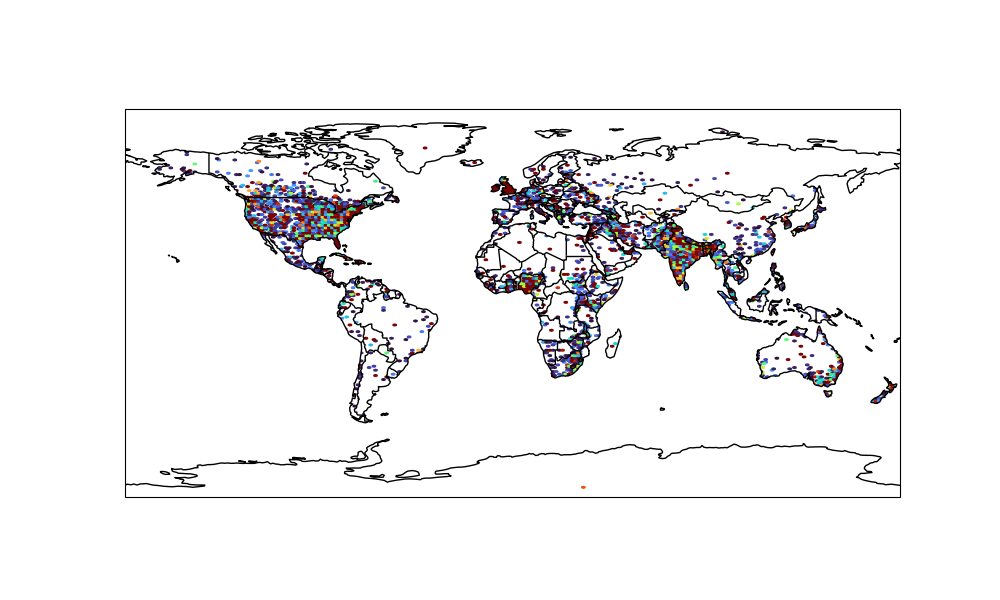

In [93]:
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

hb = ax.hexbin(
    extract["GEO_LONG"], extract["GEO_LAT"],
    C=extract["NUMARTS"],
    reduce_C_function=sum,
    gridsize=240,
    vmax=50,
    cmap="turbo"
)

land = cfeature.NaturalEarthFeature("physical", "land", "110m")
land_geom = unary_union(list(land.geometries()))
land_path = shapely_to_path(land_geom)

clip_patch = mpatches.PathPatch(
    land_path,
    transform=ccrs.PlateCarree()._as_mpl_transform(ax)
)

hb.set_clip_path(clip_patch)

ax.coastlines()
ax.add_feature(cfeature.BORDERS)

#plt.colorbar(hb, label="Count per hexagon")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()